In [10]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Annotated, Literal
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator
load_dotenv()

True

In [11]:
class Sentiment(BaseModel):
    sentiment: Annotated[str, Field(description="The sentiment of the text, either 'positive' or 'negative'")]

model = ChatGroq(model="llama-3.3-70b-versatile")
structure_model = model.with_structured_output(Sentiment)

In [12]:
class ProductState(TypedDict):
    product_review: str
    sentiment: str
    feedback: str
    alternative_product: str

In [13]:
def get_sentiment(state: ProductState) -> dict:
    sentiment_result = structure_model.invoke(state["product_review"])
    return {"sentiment": sentiment_result.sentiment}

def check_sentiment(state: ProductState) -> Literal['positive_feedback', 'negative_feedback']:
    if state["sentiment"] == "positive":
        return "positive_feedback"
    else:
        return "negative_feedback"
    
def positive_feedback(state: ProductState) -> dict:
    return {"feedback": "Thank you for your positive review!"}

def negative_feedback(state: ProductState) -> dict:
    return {"feedback": "We're sorry to hear about your experience. We will work on improving our product."}

def suggest_alternative(state: ProductState) -> dict:
    response = model.invoke(f"Suggest an alternative product to the one described in this review: {state['product_review']}")
    return {"alternative_product": response.content}

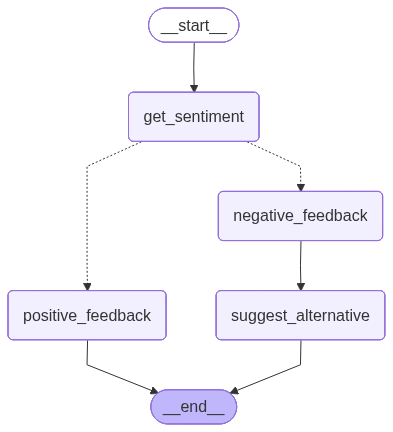

In [14]:
graph = StateGraph(ProductState)

graph.add_node('get_sentiment', get_sentiment)
graph.add_node('positive_feedback', positive_feedback)
graph.add_node('negative_feedback', negative_feedback)
graph.add_node('suggest_alternative', suggest_alternative)

graph.add_edge(START, 'get_sentiment')
graph.add_conditional_edges('get_sentiment', check_sentiment)
graph.add_edge('positive_feedback', END)
graph.add_edge('negative_feedback', 'suggest_alternative')
graph.add_edge('suggest_alternative', END)

graph.compile()

In [15]:
workflow = graph.compile()

In [16]:
initial_state = {"product_review": "I love this product! It works great and exceeded my expectations."}
workflow.invoke(initial_state)

{'product_review': 'I love this product! It works great and exceeded my expectations.',
 'sentiment': 'positive',
 'feedback': 'Thank you for your positive review!'}

In [17]:
initial_state = {"product_review": "The samsung galaxy s23 is terrible. It keeps overheating and the battery life is awful."}
workflow.invoke(initial_state)

{'product_review': 'The samsung galaxy s23 is terrible. It keeps overheating and the battery life is awful.',
 'sentiment': 'negative',
 'feedback': "We're sorry to hear about your experience. We will work on improving our product.",
 'alternative_product': 'Based on the issues mentioned with the Samsung Galaxy S23, I would suggest considering the Google Pixel 7 as an alternative. The Google Pixel 7 is known for its efficient cooling system and reliable battery life, which could address the overheating and battery life concerns mentioned in the review. Additionally, the Pixel 7 is often praised for its camera capabilities and timely software updates, making it a solid option for those looking for a hassle-free smartphone experience.'}